<a href="https://colab.research.google.com/github/Alahin04/Actividad-An-lisis-Cambio-Clim-tico---Pr-ctica-SQL/blob/main/An%C3%A1lisis_Cambio_Clim%C3%A1tico_SQL_IMD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TRABAJO PRÁCTICO - ANÁLISIS DE TEMPERATURA GLOBAL CON SQL Y PYTHON**

---


**Curso:** Introducción a la Minería de Datos


---


**Estudiante:** Samuel Alahin López Cadavid


In [147]:
#Instalación e importación de librerías
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga de datos
Se carga la base de datos GlobalLandTemperaturesByCountry.csv obtenida de Kaggle (Berkeley Earth),
que contiene registros mensuales de temperatura promedio por país desde 1743 hasta 2013.

In [148]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [149]:
df = pd.read_csv('/content/drive/MyDrive/GlobalLandTemperaturesByCountry.csv')
print(f"\n Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("\n Primeras filas:")
df.head(10)


 Dimensiones: 577,462 filas × 4 columnas

 Primeras filas:


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland
5,1744-04-01,1.530,4.680,Åland
6,1744-05-01,6.702,1.789,Åland
7,1744-06-01,11.609,1.577,Åland
8,1744-07-01,15.342,1.410,Åland
9,1744-08-01,NaN,NaN,Åland


In [150]:
print("EXPLORACIÓN INICIAL DEL DATASET")
#Tipos de datos
print("\n Tipos de datos:")
print(df.dtypes)

#Valores faltantes
print("\n Valores faltantes por columna:")
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Faltantes': nulos, 'Porcentaje (%)': porcentaje})
print(resumen_nulos)

#Número de países
print(f"\n Número de países: {df['Country'].nunique()}")

#Rango temporal (antes de convertir)
print(f"\n Fecha mínima: {df['dt'].min()}")
print(f" Fecha máxima: {df['dt'].max()}")



EXPLORACIÓN INICIAL DEL DATASET

 Tipos de datos:
dt                                object
AverageTemperature               float64
AverageTemperatureUncertainty    float64
Country                           object
dtype: object

 Valores faltantes por columna:
                               Faltantes  Porcentaje (%)
dt                                     0            0.00
AverageTemperature                 32651            5.65
AverageTemperatureUncertainty      31912            5.53
Country                                0            0.00

 Número de países: 243

 Fecha mínima: 1743-11-01
 Fecha máxima: 2013-09-01


## 2. Exploración inicial
La base contiene 577,462 registros de 243 países. Se identificaron 32,651 valores faltantes
en AverageTemperature (5.65%) y 31,912 en AverageTemperatureUncertainty (5.53%).
Estos registros serán eliminados para el análisis agregado.

In [151]:
#Transformación y limpieza
#Convertir 'dt' a tipo fecha
df['dt'] = pd.to_datetime(df['dt'])

#Extraer año
df['Year'] = df['dt'].dt.year

#Eliminar filas sin temperatura (para los cálculos agregados)
df_clean = df.dropna(subset=['AverageTemperature']).copy()
print(f" Limpieza completada")
print(f"   Registros originales : {len(df):,}")
print(f"   Registros sin nulos  : {len(df_clean):,}")
print(f"   Registros eliminados : {len(df) - len(df_clean):,}")
print(f"\n  Rango de años: {df_clean['Year'].min()} — {df_clean['Year'].max()}")
df_clean.head()

 Limpieza completada
   Registros originales : 577,462
   Registros sin nulos  : 544,811
   Registros eliminados : 32,651

  Rango de años: 1743 — 2013


,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year
0,1743-11-01,4.384,2.294,Åland,1743
5,1744-04-01,1.530,4.680,Åland,1744
6,1744-05-01,6.702,1.789,Åland,1744
7,1744-06-01,11.609,1.577,Åland,1744
8,1744-07-01,15.342,1.410,Åland,1744


In [153]:
# Ahora en SQLite
#base de datos en memoria
conn = sqlite3.connect('clima.db')
# Cargar el DataFrame limpio como tabla SQL
df_clean.to_sql('temperaturas', conn, if_exists='replace', index=False)

print(" Datos cargados en SQLite exitosamente")
print(f"Tabla: 'temperaturas'")
print(f"Registros: {len(df_clean):,}")

# Verificar con una consulta simple
verificacion = pd.read_sql_query("SELECT COUNT(*) AS total FROM temperaturas", conn)
print(f"\n Verificación SQL: {verificacion['total'][0]:,} registros en la tabla")

 Datos cargados en SQLite exitosamente
Tabla: 'temperaturas'
Registros: 544,811

 Verificación SQL: 544,811 registros en la tabla


## 3. Limpieza y carga en SQLite
Se convierte la columna dt a formato fecha, se extrae el año y se eliminan registros sin
temperatura. La base limpia se carga en SQLite para realizar consultas SQL.

In [154]:
#Estructura y cobertura de la base de datos en SQLite
print("=" * 55)
print("   SQL 1 — Cobertura general del dataset")
print("=" * 55)

query1 = """
SELECT
    COUNT(*)                        AS total_registros,
    COUNT(DISTINCT Country)         AS total_paises,
    MIN(Year)                       AS anio_minimo,
    MAX(Year)                       AS anio_maximo,
    ROUND(AVG(AverageTemperature), 2) AS temp_promedio_global
FROM temperaturas
"""

resultado1 = pd.read_sql_query(query1, conn)
print(resultado1.to_string(index=False))

   SQL 1 — Cobertura general del dataset
 total_registros  total_paises  anio_minimo  anio_maximo  temp_promedio_global
          544811           242         1743         2013                 17.19


In [155]:
#Tabla agregada por país y año
print("Temperatura agregada por País y Año")

query2 = """
SELECT
    Country                                         AS pais,
    Year                                            AS anio,
    ROUND(AVG(AverageTemperature), 3)               AS temp_promedio_anual,
    ROUND(MIN(AverageTemperature), 3)               AS temp_minima_anual,
    ROUND(MAX(AverageTemperature), 3)               AS temp_maxima_anual,
    COUNT(*)                                        AS num_observaciones,
    ROUND(AVG(AverageTemperatureUncertainty), 3)    AS incertidumbre_promedio
FROM temperaturas
GROUP BY Country, Year
ORDER BY Country, Year
"""

df_anual = pd.read_sql_query(query2, conn)

# Guardar en SQLite para consultas posteriores
df_anual.to_sql('temp_anual', conn, if_exists='replace', index=False)

print(f"Tabla agregada creada: {len(df_anual):,} filas")
print(f"Países × Años únicos")
df_anual.head(10)

Temperatura agregada por País y Año
Tabla agregada creada: 45,915 filas
Países × Años únicos


,pais,anio,temp_promedio_anual,temp_minima_anual,temp_maxima_anual,num_observaciones,incertidumbre_promedio
0,Afghanistan,1838,18.380,7.475,26.877,7,2.756
1,Afghanistan,1840,13.413,0.735,27.739,11,2.502
2,Afghanistan,1841,13.998,-0.883,27.104,10,2.452
3,Afghanistan,1842,15.155,3.330,25.798,9,2.381
4,Afghanistan,1843,13.756,0.674,26.748,12,2.353
5,Afghanistan,1844,13.149,0.959,26.576,12,2.235
6,Afghanistan,1845,13.306,0.421,26.383,12,2.371
7,Afghanistan,1846,14.031,1.194,27.278,12,2.442
8,Afghanistan,1847,13.476,-0.402,27.223,12,2.458
9,Afghanistan,1848,13.136,-1.928,26.706,12,2.030


## Pregunta 1 — ¿Qué países tienen las mayores temperaturas promedio anuales?
Se consulta sobre temp_anual para identificar los países más cálidos históricamente,
filtrando países con al menos 50 años de datos para mayor confiabilidad.

Top 15 países más cálidos (promedio histórico)
                             pais  temp_historica_promedio  anios_con_datos
                         Djibouti                    28.82              139
                             Mali                    28.44              158
                     Burkina Faso                    28.07              157
                          Senegal                    27.96              158
                            Aruba                    27.92              175
             United Arab Emirates                    27.65              159
                       Mauritania                    27.58              165
                           Gambia                    27.53              158
                            Niger                    27.44              150
                          Curaçao                    27.35              175
                            Palau                    27.22              132
                    Palmyra Atoll        

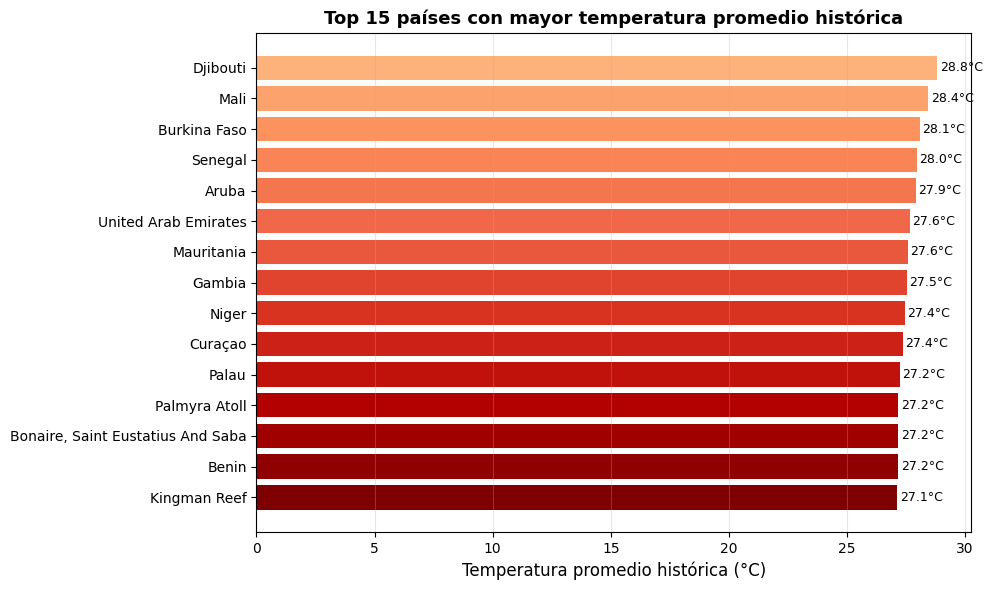

In [156]:
print("Top 15 países más cálidos (promedio histórico)")

query3 = """
SELECT
    pais,
    ROUND(AVG(temp_promedio_anual), 2)  AS temp_historica_promedio,
    COUNT(anio)                          AS anios_con_datos
FROM temp_anual
GROUP BY pais
HAVING anios_con_datos >= 50
ORDER BY temp_historica_promedio DESC
LIMIT 15
"""

resultado3 = pd.read_sql_query(query3, conn)
print(resultado3.to_string(index=False))

#Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
colores = plt.cm.OrRd(np.linspace(0.4, 1.0, len(resultado3)))
bars = ax.barh(resultado3['pais'], resultado3['temp_historica_promedio'], color=colores)
ax.set_xlabel('Temperatura promedio histórica (°C)', fontsize=12)
ax.set_title('Top 15 países con mayor temperatura promedio histórica', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, resultado3['temp_historica_promedio']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}°C', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_paises_calidos.png', dpi=150, bbox_inches='tight')
plt.show()

## Pregunta 2 — ¿Qué países muestran mayor variación de temperatura?
Se calcula la diferencia entre la temperatura máxima y mínima anual registrada por país,
lo que indica qué tan extremo es su clima a lo largo del tiempo.

Países con mayor variación de temperatura
         pais  rango_temp  temp_max  temp_min  anios_con_datos
       Canada       23.41      0.79    -22.62              216
       Russia       19.71     -1.63    -21.34              202
   Kazakhstan       17.73      8.94     -8.79              202
North America       17.63      6.44    -11.19              215
       Kuwait       15.62     27.64     12.02              175
   Uzbekistan       15.34     16.19      0.85              185
United States       15.01     12.23     -2.78              215
 Turkmenistan       14.92     18.61      3.69              186
      Algeria       14.87     25.22     10.34              227
       Jordan       14.37     22.23      7.86              205
      Finland       13.14      4.06     -9.08              267
   Gaza Strip       12.86     21.90      9.04              206
       Israel       12.60     22.31      9.71              205
      Ukraine       12.53     10.91     -1.62              267
      Estonia

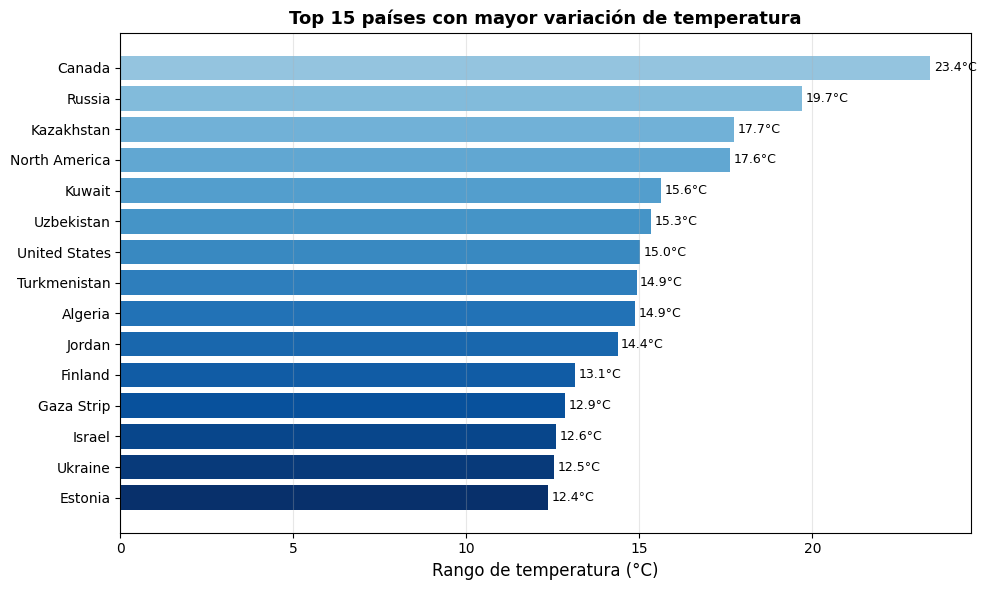

Gráfico guardado


In [157]:
print("Países con mayor variación de temperatura")

query4 = """
SELECT
    pais,
    ROUND(MAX(temp_promedio_anual) - MIN(temp_promedio_anual), 2)   AS rango_temp,
    ROUND(MAX(temp_promedio_anual), 2)                               AS temp_max,
    ROUND(MIN(temp_promedio_anual), 2)                               AS temp_min,
    COUNT(anio)                                                       AS anios_con_datos
FROM temp_anual
GROUP BY pais
HAVING anios_con_datos >= 50
ORDER BY rango_temp DESC
LIMIT 15
"""

resultado4 = pd.read_sql_query(query4, conn)
print(resultado4.to_string(index=False))

#Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
colores2 = plt.cm.Blues(np.linspace(0.4, 1.0, len(resultado4)))
bars2 = ax.barh(resultado4['pais'], resultado4['rango_temp'], color=colores2)
ax.set_xlabel('Rango de temperatura (°C)', fontsize=12)
ax.set_title('Top 15 países con mayor variación de temperatura', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars2, resultado4['rango_temp']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}°C', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_variacion_temp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

## Pregunta 3 — ¿Qué tan completa es la información por país y por año?
Se evalúa la completitud antes del JOIN sobre temp_anual, analizando cuántos años
reporta cada país y cuántos países reportan en cada año.

In [158]:
# PREGUNTA 3 — Completitud por país y por año (sobre temp_anual)

query_p3_pais = """
SELECT
    pais,
    COUNT(anio)                                                          AS anios_con_datos,
    ROUND(COUNT(anio) * 100.0 / (MAX(anio) - MIN(anio) + 1), 1)        AS pct_completitud
FROM temp_anual
GROUP BY pais
ORDER BY pct_completitud ASC
LIMIT 15
"""
df_p3_pais = pd.read_sql_query(query_p3_pais, conn)
df_p3_pais

,pais,anios_con_datos,pct_completitud
0,Mauritius,142,62.6
1,Reunion,142,62.6
2,Comoros,150,66.1
3,Madagascar,150,66.1
4,Mayotte,150,66.1
5,Seychelles,150,66.1
6,Niger,150,76.9
7,Bahamas,211,82.4
8,Tanzania,136,82.9
9,Christmas Island,159,84.1


In [159]:
query_p3_anio = """
SELECT
    anio,
    COUNT(DISTINCT pais) AS paises_con_datos
FROM temp_anual
GROUP BY anio
ORDER BY anio
"""
df_p3_anio = pd.read_sql_query(query_p3_anio, conn)
df_p3_anio

,anio,paises_con_datos
0,1743,50
1,1744,50
2,1745,50
3,1750,50
4,1751,50
...,...,...
262,2009,242
263,2010,242
264,2011,242
265,2012,242


## Parte abierta — Indicador: Población (Banco Mundial)
Se integra el indicador de población total por país (SP.POP.TOTL) descargado del Banco Mundial. La tabla viene en formato ancho (un año por columna) y debe transformarse a formato largo antes de integrarse con la base de temperatura.

In [160]:
nombre_pop = '/content/drive/MyDrive/API_SP.POP.TOTL_DS2_en_csv_v2_127039.csv'
print(f" Archivo recibido: {nombre_pop}")

 Archivo recibido: /content/drive/MyDrive/API_SP.POP.TOTL_DS2_en_csv_v2_127039.csv


In [161]:
#Leer y limpiar el archivo del Banco Mundial
df_pop_raw = pd.read_csv(nombre_pop, skiprows=4)

print(" Archivo leído")
print(f"   Dimensiones: {df_pop_raw.shape}")
print(f"\n Primeras columnas: {list(df_pop_raw.columns[:8])}")
df_pop_raw.head(3)

 Archivo leído
   Dimensiones: (266, 71)

 Primeras columnas: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963']


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN


In [162]:
#Pivoteo: formato ancho → formato largo

print("PIVOTEO: Formato ancho → Formato largo")

id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
year_cols = [col for col in df_pop_raw.columns if str(col).isdigit() and len(str(col)) == 4]

print(f"Años disponibles: {year_cols[0]} — {year_cols[-1]}")

df_pop_long = df_pop_raw[id_vars + year_cols].melt(
    id_vars=id_vars,
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

df_pop_long['Year']  = df_pop_long['Year'].astype(int)
df_pop_long['Value'] = pd.to_numeric(df_pop_long['Value'], errors='coerce')

df_pop_long = df_pop_long.rename(columns={
    'Country Name'  : 'Country',
    'Country Code'  : 'Country_Code',
    'Indicator Name': 'Indicator_Name',
    'Indicator Code': 'Indicator_Code'
})

df_pop_long = df_pop_long.dropna(subset=['Value'])

print(f"Registros con valor: {len(df_pop_long):,}")
df_pop_long.head(8)

PIVOTEO: Formato ancho → Formato largo
Años disponibles: 1960 — 2025
Registros con valor: 17,195


,Country,Country_Code,Indicator_Name,Indicator_Code,Year,Value
0,Aruba,ABW,"Population, total",SP.POP.TOTL,1960,54922.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,1960,130075728.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1960,9035043.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,1960,97630925.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,1960,5231654.0
5,Albania,ALB,"Population, total",SP.POP.TOTL,1960,1608800.0
6,Andorra,AND,"Population, total",SP.POP.TOTL,1960,9510.0
7,Arab World,ARB,"Population, total",SP.POP.TOTL,1960,91540853.0


In [163]:
#Tabla de Población en SQLite
df_pop_long.to_sql('poblacion', conn, if_exists='replace', index=False)

verificacion = pd.read_sql_query("SELECT COUNT(*) AS total FROM poblacion", conn)
print(f"Tabla 'poblacion' cargada en SQLite")
print(f"Registros: {verificacion['total'][0]:,}")

Tabla 'poblacion' cargada en SQLite
Registros: 17,195


In [164]:
#Verificar correspondencia antes del JOIN
paises_temp = set(df_anual['pais'].unique())
paises_pop  = set(df_pop_long['Country'].unique())

con_match       = paises_temp & paises_pop
sin_match_temp  = paises_temp - paises_pop

print(f" Países en temperatura          : {len(paises_temp)}")
print(f" Países en población            : {len(paises_pop)}")
print(f" Países con correspondencia      : {len(con_match)}")
print(f" En tempeeatura pero NO en población  : {len(sin_match_temp)}")
print(f"\n Ejemplos sin match:")
print(sorted(list(sin_match_temp))[:10])

 Países en temperatura          : 242
 Países en población            : 265
 Países con correspondencia      : 163
 En tempeeatura pero NO en población  : 79

 Ejemplos sin match:
['Africa', 'Anguilla', 'Antigua And Barbuda', 'Asia', 'Bahamas', 'Baker Island', 'Bonaire, Saint Eustatius And Saba', 'Bosnia And Herzegovina', 'Burma', 'Cape Verde']


## Integración de fuentes — JOIN temperatura + población
Se realiza un INNER JOIN entre temp_anual y poblacion usando país y año como llaves.
Solo quedan los registros donde ambas fuentes tienen datos, generando la tabla_final
que será usada para responder las preguntas del análisis guiado.



In [165]:
#JOIN entre temperatura y población (tabla_final)
query_join = """
SELECT
    t.pais,
    t.anio,
    t.temp_promedio_anual,
    t.temp_minima_anual,
    t.temp_maxima_anual,
    t.incertidumbre_promedio,
    p.Value AS poblacion
FROM temp_anual t
INNER JOIN poblacion p
    ON  t.pais = p.Country
    AND t.anio = p.Year
WHERE p.Value IS NOT NULL
ORDER BY t.pais, t.anio
"""

df_final = pd.read_sql_query(query_join, conn)
df_final.to_sql('tabla_final', conn, if_exists='replace', index=False)

print(f" tabla_final creada")
print(f"   Registros : {len(df_final):,}")
print(f"   Países    : {df_final['pais'].nunique()}")
print(f"   Años      : {df_final['anio'].min()} — {df_final['anio'].max()}")
df_final.head()

 tabla_final creada
   Registros : 8,802
   Países    : 163
   Años      : 1960 — 2013


,pais,anio,temp_promedio_anual,temp_minima_anual,temp_maxima_anual,incertidumbre_promedio,poblacion
0,Afghanistan,1960,13.985,1.811,26.600,0.442,9035043.0
1,Afghanistan,1961,14.065,1.482,27.363,0.398,9214083.0
2,Afghanistan,1962,13.769,0.616,26.961,0.406,9404406.0
3,Afghanistan,1963,15.033,2.500,27.246,0.401,9604487.0
4,Afghanistan,1964,13.085,-4.254,26.470,0.449,9814318.0


## Análisis guiado — Preguntas sobre la tabla final
Las siguientes preguntas se responden sobre tabla_final, resultado de la integración
entre temperatura y población para el periodo 1960–2013.

## Pregunta 1 — ¿Qué países tienen las mayores temperaturas promedio anuales?

In [166]:
#Países con mayores temperaturas promedio anuales
query_p1 = """
SELECT
    pais,
    ROUND(AVG(temp_promedio_anual), 2) AS temp_promedio_historica
FROM tabla_final
GROUP BY pais
ORDER BY temp_promedio_historica DESC
LIMIT 15
"""
df_p1 = pd.read_sql_query(query_p1, conn)
print("Pregunta 1 — Países más cálidos:")
df_p1

Pregunta 1 — Países más cálidos:


,pais,temp_promedio_historica
0,Djibouti,29.18
1,Mali,28.90
2,Burkina Faso,28.51
3,Senegal,28.44
4,Aruba,28.40
5,United Arab Emirates,28.23
6,Mauritania,28.11
7,Niger,27.86
8,Palau,27.59
9,Benin,27.55


## Pregunta 2 — ¿Qué países muestran mayor variación de temperatura?

In [167]:
#Países con mayor variación de temperatura

query_p2 = """
SELECT
    pais,
    ROUND(MAX(temp_promedio_anual) - MIN(temp_promedio_anual), 2) AS variacion_temp
FROM tabla_final
GROUP BY pais
ORDER BY variacion_temp DESC
LIMIT 15
"""
df_p2 = pd.read_sql_query(query_p2, conn)
print("Mayor variación de temperatura:")
df_p2

Mayor variación de temperatura:


,pais,variacion_temp
0,Uzbekistan,5.25
1,Kazakhstan,5.21
2,Turkmenistan,5.19
3,Canada,5.16
4,Greenland,5.04
5,Denmark,4.93
6,Ukraine,4.73
7,Finland,4.55
8,Mongolia,4.40
9,Moldova,4.24


## Pregunta 3 - ¿Qué tan completa es la información por país y por año?

In [168]:
#Completitud por país y por año

#Por país
query_p3_pais = """
SELECT
    pais,
    COUNT(*)                             AS total_registros,
    ROUND(COUNT(*) * 100.0 / 54, 1)     AS pct_completitud
FROM tabla_final
GROUP BY pais
ORDER BY total_registros ASC
"""
df_p3_pais = pd.read_sql_query(query_p3_pais, conn)
print(f"Países en tabla final: {len(df_p3_pais)}")
df_p3_pais.head(15)

Países en tabla final: 163


,pais,total_registros,pct_completitud
0,Afghanistan,54,100.0
1,Albania,54,100.0
2,Algeria,54,100.0
3,American Samoa,54,100.0
4,Andorra,54,100.0
5,Angola,54,100.0
6,Argentina,54,100.0
7,Armenia,54,100.0
8,Aruba,54,100.0
9,Australia,54,100.0


In [169]:
#Por año
query_p3_anio = """
SELECT
    anio,
    COUNT(DISTINCT pais)    AS paises_con_datos
FROM tabla_final
GROUP BY anio
ORDER BY anio
"""
df_p3_anio = pd.read_sql_query(query_p3_anio, conn)
print("Completitud por año:")
df_p3_anio.head(15)

Completitud por año:


,anio,paises_con_datos
0,1960,163
1,1961,163
2,1962,163
3,1963,163
4,1964,163
5,1965,163
6,1966,163
7,1967,163
8,1968,163
9,1969,163


Observación: Cantidad de países que se perdieron en el JOIN

In [170]:
#Cantidad de países que se perdieron en el JOIN
query_perdidos = """
SELECT COUNT(DISTINCT pais) AS paises_perdidos
FROM temp_anual
WHERE pais NOT IN (SELECT DISTINCT pais FROM tabla_final)
"""
df_perdidos = pd.read_sql_query(query_perdidos, conn)
print("Países perdidos en el JOIN:")
df_perdidos

Países perdidos en el JOIN:


,paises_perdidos
0,79


## Pregunta 4 - ¿Existen diferencias visibles entre países al comparar temperatura con el indicador seleccionado de la API?
Se compara la temperatura promedio histórica con la población promedio por país mediante
un gráfico de dispersión, buscando patrones descriptivos entre ambas variables.

In [171]:
#Diferencias visibles entre países: temperatura vs población

query_p4 = """
SELECT
    pais,
    ROUND(AVG(temp_promedio_anual), 2)      AS temp_promedio,
    ROUND(AVG(poblacion) / 1000000, 1)      AS poblacion_promedio_millones
FROM tabla_final
GROUP BY pais
ORDER BY temp_promedio DESC
LIMIT 20
"""
df_p4 = pd.read_sql_query(query_p4, conn)
print("Pregunta 4 — Temperatura vs Población:")
df_p4

Pregunta 4 — Temperatura vs Población:


,pais,temp_promedio,poblacion_promedio_millones
0,Djibouti,29.18,0.5
1,Mali,28.90,9.5
2,Burkina Faso,28.51,9.3
3,Senegal,28.44,7.5
4,Aruba,28.40,0.1
5,United Arab Emirates,28.23,2.3
6,Mauritania,28.11,1.9
7,Niger,27.86,8.6
8,Palau,27.59,0.0
9,Benin,27.55,5.4


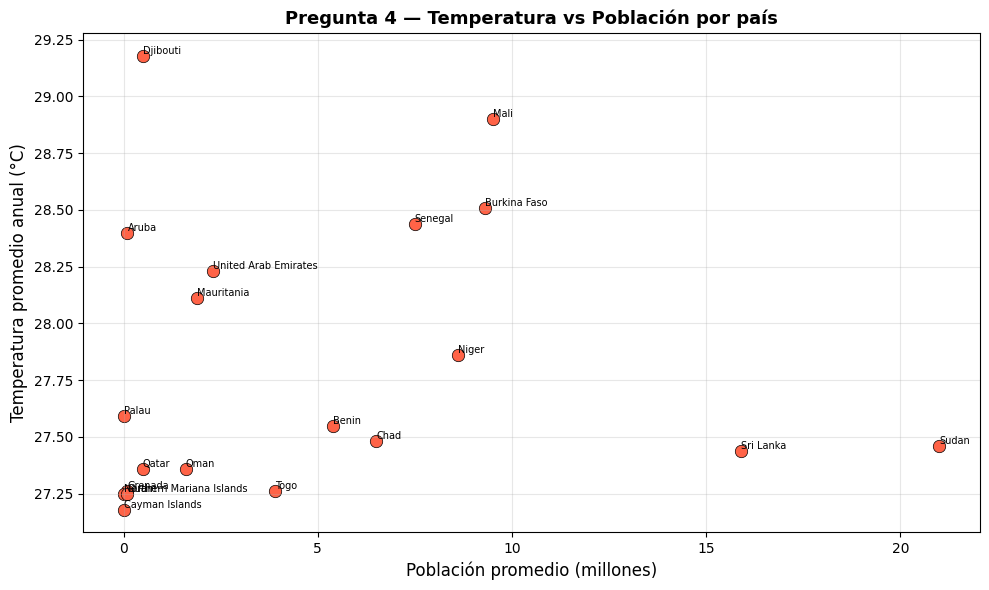

In [172]:
#Gráfico Pregunta 4
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_p4['poblacion_promedio_millones'], df_p4['temp_promedio'],
           color='tomato', s=80, edgecolors='black', linewidth=0.5)

for _, row in df_p4.iterrows():
    ax.annotate(row['pais'],
                (row['poblacion_promedio_millones'], row['temp_promedio']),
                fontsize=7, ha='left', va='bottom')

ax.set_xlabel('Población promedio (millones)', fontsize=12)
ax.set_ylabel('Temperatura promedio anual (°C)', fontsize=12)
ax.set_title('Pregunta 4 — Temperatura vs Población por país', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Pregunta 5 - ¿Qué limitaciones se observan en la integración de ambas fuentes?
Se cuantifica la pérdida de información generada por el JOIN y se identifican las
principales limitaciones metodológicas del proceso de integración.

In [173]:
#Limitaciones de la integración
query_p5 = """
SELECT
    'Países en temperatura'             AS fuente,
    COUNT(DISTINCT pais)                AS total
FROM temp_anual

UNION ALL

SELECT
    'Países en población',
    COUNT(DISTINCT Country)
FROM poblacion

UNION ALL

SELECT
    'Países en tabla final (JOIN)',
    COUNT(DISTINCT pais)
FROM tabla_final
"""
df_p5 = pd.read_sql_query(query_p5, conn)
print("Países perdidos en la integración:")
df_p5

Países perdidos en la integración:


,fuente,total
0,Países en temperatura,242
1,Países en población,265
2,Países en tabla final (JOIN),163


**Esto evidencia las siguientes limitaciones:**
1. Nombres de países no estandarizados entre ambas fuentes, lo que
   impidió que 79 países de temperatura encontraran correspondencia.

2. Cobertura temporal asimétrica: la temperatura tiene datos desde 1743
   pero la población solo desde 1960, reduciendo el análisis a 54 años.

3. La agregación de datos mensuales a anuales puede ocultar variaciones
   estacionales importantes.

4. Los valores nulos eliminados en la limpieza (5.65% de la temperatura)
   pueden afectar la representatividad de algunos países.

## Componente abierto — ¿Ha aumentado la temperatura promedio global con el tiempo?
Pregunta propia de análisis: se estudia la evolución de la temperatura promedio global
entre 1960 y 2013 para identificar si existe una tendencia de calentamiento visible en los datos.

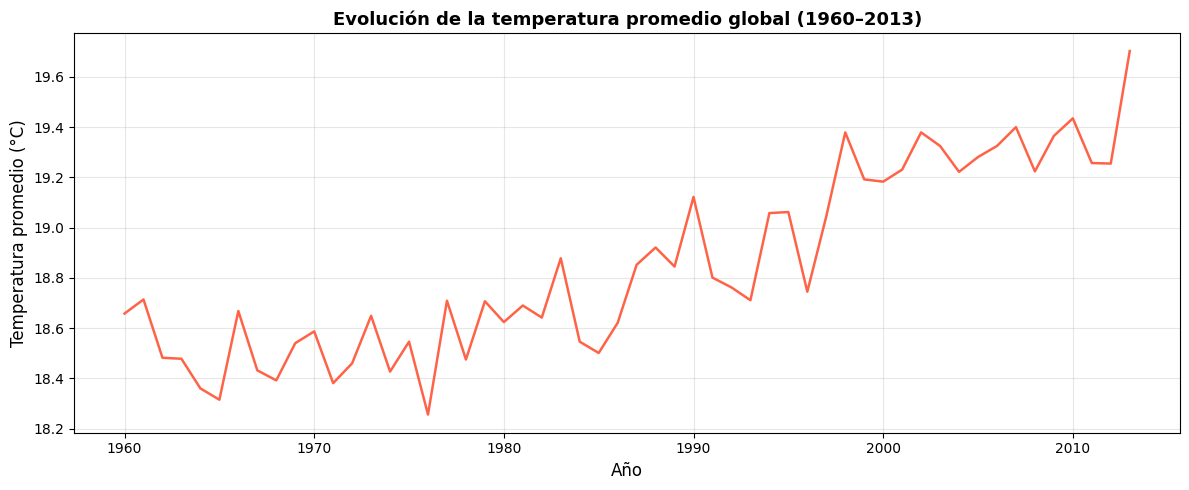

In [174]:
#¿Ha aumentado la temperatura promedio global con el tiempo?
query_abierto = """
SELECT
    anio,
    ROUND(AVG(temp_promedio_anual), 3) AS temp_global_promedio
FROM tabla_final
WHERE anio BETWEEN 1960 AND 2013
GROUP BY anio
ORDER BY anio
"""
df_abierto = pd.read_sql_query(query_abierto, conn)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_abierto['anio'], df_abierto['temp_global_promedio'],
        color='tomato', linewidth=1.8)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Temperatura promedio (°C)', fontsize=12)
ax.set_title('Evolución de la temperatura promedio global (1960–2013)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##Interpretación

El gráfico muestra la evolución de la temperatura promedio global
entre 1960 y 2013. Se pueden identificar los siguientes hallazgos:

1. Tendencia al alza: la temperatura promedio pasó de aproximadamente
   18.5°C en 1960 a cerca de 19.6°C en 2013, lo que representa un
   aumento de más de 1°C en 53 años.

2. Aceleración del calentamiento: antes de 1980 la temperatura
   oscilaba entre 18.3°C y 18.8°C con variaciones frecuentes.
   A partir de 1980 se observa una tendencia ascendente más sostenida
   y pronunciada.

3. Variaciones anuales: aunque la tendencia es creciente, se observan
   fluctuaciones año a año, lo que es normal dado que la temperatura
   depende de múltiples factores climáticos.

4. Periodo más cálido: los años más recientes (2000-2013) concentran
   las temperaturas más altas del periodo analizado, siendo 2013
   el año con mayor temperatura registrada.

Esto es consistente con los reportes científicos sobre el cambio
climático global, aunque este análisis es puramente descriptivo
y no permite establecer relaciones causales.

## Conclusiones
El análisis permitió identificar que los países más cálidos se concentran en zonas
tropicales, mientras que los de mayor variación corresponden a regiones con climas
extremos. La integración con el indicador de población redujo la cobertura temporal
al periodo 1960–2013 y excluyó países sin correspondencia de nombres entre fuentes.
Se observa una tendencia de calentamiento global en el periodo analizado.